# Building a BPE Tokenizer from Scratch

> ↩ **Previous in the series:** [Building a Transformer from Scratch](transformer.ipynb)


How text really becomes numbers: Byte-Pair Encoding, the algorithm behind the GPT and Llama tokenizers. Pure Python — no PyTorch, no training a network, no libraries at all.

Every notebook in this series has quietly leaned on a tokenizer. The [embeddings](embeddings.ipynb) and [transformer](transformer.ipynb) notebooks used the simplest possible one — every character gets an ID, vocabulary of 65 — and the [finetuning notebook](finetuning.ipynb) silently jumped to TinyLlama's 32,000-token vocabulary without ever asking where those 32,000 tokens came from. This notebook closes that gap. It's the one notebook in the series with **no neural network in it**: a tokenizer is trained (it learns from data!) but by counting, not by gradient descent.

### The problem: what should a token be?

A model predicts one token at a time and holds a fixed number of tokens in its context window, so the choice of token is a real trade-off, not bookkeeping:

| Token = | Vocab size | "To be or not to be" | The catch |
|---------|-----------|----------------------|-----------|
| one character | ~65–256 | 18 tokens | Sequences are long: the model burns its context window spelling, and must learn what a "word" even is |
| one word | 100k+ and never enough | 6 tokens | Any unseen word — typo, name, `LayerNorm`, German compound — has no ID at all |
| **a learned chunk (BPE)** | **your choice (32k–200k)** | **~6–8 tokens** | The subject of this notebook |

BPE's bargain: **start from characters (nothing is ever un-encodable) and let the data itself decide which frequent chunks deserve to be single tokens.** Common words end up as one token, rare words as a few pieces, and gibberish still works character by character. The algorithm is almost embarrassingly simple — repeatedly find the most frequent adjacent pair and glue it together — and it dates from 1994 as a *compression* trick (Philip Gage), pressed into NLP service in 2016 and used by GPT-2 onward.

| Step | What we build | Why we need it |
|------|--------------|----------------|
| 1 | Text as bytes | A universal 256-token starting vocabulary — no character can ever be unknown |
| 2 | Counting pairs | Find the most frequent adjacent pair — the one that deserves its own token |
| 3 | The merge | Replace every occurrence of that pair with a brand-new token ID |
| 4 | The training loop | Repeat count-and-merge until the vocabulary hits its budget |
| 5 | Encode & decode | Apply the learned merges to *new* text, and reverse them |
| 6 | Training on Shakespeare | A real corpus: watch the vocabulary and the compression grow |
| 7 | The weirdness tokens explain | Spelling, arithmetic, non-English costs — LLM folklore, demystified |
| 8 | What production tokenizers add | Regex pre-splitting, special tokens, and the road to 32k/100k vocabs |


In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
# That's the only import, and it's just for one plot. The tokenizer itself is plain Python.


## Step 1: Text as bytes — the universal starting vocabulary

Before merging chunks we need atoms — a base vocabulary that can represent *any* text. Characters seem natural, but "all characters" is enormous (Unicode defines ~150,000, with more added yearly) and mostly unused. The trick every modern tokenizer uses: go one level lower, to **bytes**.

Python's `.encode('utf-8')` turns any string into a sequence of bytes — integers 0–255. UTF-8 is the encoding that runs the internet, and it's variable-length: plain English letters take 1 byte each, `é` takes 2, `感` takes 3, an emoji takes 4. The details don't matter here; what matters is the guarantee:

- **The base vocabulary is exactly 256 tokens**, fixed forever, tiny.
- **Nothing is ever un-encodable.** Any string in any language — code, emoji, typos, languages invented next year — is some sequence of bytes 0–255. Word-level tokenizers need an `<UNK>` (unknown) escape hatch; byte-level BPE simply never does.

So our token IDs start life as raw bytes, `0..255`, and every token BPE invents from here on gets the next free number: the first merge creates token `256`, then `257`, and so on. A token ID is *just an integer with a byte-string behind it* — exactly what the embedding tables in the other notebooks are indexed with.


In [2]:
s = "hello é 感 👋"
b = list(s.encode('utf-8'))
print(f'string: {s!r}   ({len(s)} characters)')
print(f'bytes : {b}   ({len(b)} bytes)')

# Variable length per character: ASCII 1 byte, é 2, 感 3, the emoji 4.
for ch in ['h', 'é', '感', '👋']:
    print(f'  {ch!r} -> {list(ch.encode("utf-8"))}')


string: 'hello é 感 👋'   (11 characters)
bytes : [104, 101, 108, 108, 111, 32, 195, 169, 32, 230, 132, 159, 32, 240, 159, 145, 139]   (17 bytes)
  'h' -> [104]
  'é' -> [195, 169]
  '感' -> [230, 132, 159]
  '👋' -> [240, 159, 145, 139]


## Step 2: Counting pairs

The entire learning signal in BPE is one statistic: **which two adjacent tokens appear next to each other most often?** If `t` followed by `h` is the most common pair in English text, then `th` clearly deserves to be a single token — every occurrence currently costs 2 tokens and could cost 1.

`get_stats` walks the sequence once, counting every adjacent pair into a dictionary. `zip(ids, ids[1:])` is the idiomatic way to visit consecutive pairs: it lines the sequence up against itself shifted by one — the same shift-by-one trick the other notebooks used to manufacture (input → next token) training examples, here used to see neighbors.


In [3]:
def get_stats(ids):
    """Count how often each adjacent pair occurs. {(id, id): count}"""
    counts = {}
    for pair in zip(ids, ids[1:]):   # iterate consecutive pairs: (ids[0],ids[1]), (ids[1],ids[2]), ...
        counts[pair] = counts.get(pair, 0) + 1
    return counts

demo = "the theatre thermometer there"
ids = list(demo.encode('utf-8'))
stats = get_stats(ids)

top = sorted(stats.items(), key=lambda kv: -kv[1])[:5]
print(f'text: {demo!r}  ->  {len(ids)} byte tokens\n')
print('most frequent adjacent pairs:')
for (a, b), n in top:
    print(f'  ({a:3d}, {b:3d})  = {bytes([a])!r}+{bytes([b])!r}  x{n}')


text: 'the theatre thermometer there'  ->  29 byte tokens

most frequent adjacent pairs:
  (116, 104)  = b't'+b'h'  x4
  (104, 101)  = b'h'+b'e'  x4
  ( 32, 116)  = b' '+b't'  x3
  (101, 114)  = b'e'+b'r'  x3
  (101,  32)  = b'e'+b' '  x2


## Step 3: The merge

Once we've picked the winning pair, we **mint a new token** for it: pick the next unused ID (starting at 256) and rewrite the sequence, replacing every occurrence of the pair with that single new ID. The sequence gets shorter; the vocabulary gets one entry bigger. That trade — *shorter sequences for a bigger vocabulary* — is the entire economics of tokenization.

`merge` is a single left-to-right pass. One subtlety worth noticing: because the pass consumes both members of a matched pair and moves on, overlapping matches resolve left-first — `aaa` with pair `(a,a)` becomes `(aa) a`, not `a (aa)`. Any consistent rule works; this is the standard one.


In [4]:
def merge(ids, pair, new_id):
    """Replace every occurrence of `pair` in `ids` with the single token `new_id`."""
    out = []
    i = 0
    while i < len(ids):
        if i < len(ids) - 1 and (ids[i], ids[i+1]) == pair:
            out.append(new_id)   # matched: emit the new token, skip BOTH members of the pair
            i += 2
        else:
            out.append(ids[i])
            i += 1
    return out

# Merge the winner from Step 2: 'th' becomes token 256.
best = max(stats, key=stats.get)
ids2 = merge(ids, best, 256)
print(f'merging {best} = {bytes(best)!r} -> new token 256')
print(f'before: {len(ids)} tokens')
print(f'after : {len(ids2)} tokens')
print(f'sequence now: {ids2}')
print('(every 116,104 pair is gone — replaced by a single 256)')


merging (116, 104) = b'th' -> new token 256
before: 29 tokens
after : 25 tokens
sequence now: [256, 101, 32, 256, 101, 97, 116, 114, 101, 32, 256, 101, 114, 109, 111, 109, 101, 116, 101, 114, 32, 256, 101, 114, 101]
(every 116,104 pair is gone — replaced by a single 256)


## Step 4: The training loop

Training a BPE tokenizer is just Steps 2–3 in a loop: count pairs → merge the most frequent → repeat, until the vocabulary reaches its budget. Two bookkeeping structures record what was learned:

- **`merges`** — a dict `{pair: new_id}`, in the order the merges happened. Order is the crucial part: later merges build *on top of* earlier ones (`th` must exist before `th`+`e` can merge into `the`). This ordered list **is** the tokenizer; it's what OpenAI ships in a GPT tokenizer file.
- **`vocab`** — a dict `{id: bytes}`, so every token can be turned back into raw bytes for decoding. A new token's bytes are just its two parents' bytes concatenated.

Watch the merges below build hierarchically: early rounds glue characters into digraphs (`at`, `th`), later rounds glue *previous merges* into bigger units. And watch the failure mode, because our warm-up corpus is one sentence repeated: by merge 15 BPE has swallowed **the entire phrase** `the cat sat on the mat ` into a single token. Frequency is the *only* criterion — if a whole sentence repeats often enough, it becomes one token. Nothing is wrong with the algorithm; the corpus is just degenerate. Step 6's real corpus is diverse enough that only genuinely common chunks (words, name-prefixes, punctuation patterns) win.

> **Where spaces end up.** Notice merges like `at ` — the space *after* a word gets glued on, or the one before, whichever pattern is more frequent; raw BPE doesn't care. Production tokenizers standardize this (GPT-2's pre-splitting, Step 8, always attaches the *leading* space, which is why real vocabularies are full of tokens like `" the"` — and why a prompt ending in a dangling space trips models up: the space was supposed to arrive attached to the next word).


In [5]:
def train_bpe(text, vocab_size, verbose_first=10):
    """Learn `vocab_size - 256` merges from text. Returns (merges, vocab, stats_history)."""
    assert vocab_size >= 256
    ids = list(text.encode('utf-8'))
    n_bytes = len(ids)
    merges = {}                                   # (id, id) -> new id, in learned order
    vocab = {i: bytes([i]) for i in range(256)}   # id -> the raw bytes it stands for
    history = []                                  # (vocab size, compression ratio) after each merge

    for i in range(vocab_size - 256):
        stats = get_stats(ids)
        pair = max(stats, key=stats.get)          # the most frequent adjacent pair right now
        new_id = 256 + i
        ids = merge(ids, pair, new_id)
        merges[pair] = new_id
        vocab[new_id] = vocab[pair[0]] + vocab[pair[1]]   # its bytes = parents' bytes glued
        history.append((new_id + 1, n_bytes / len(ids)))
        if i < verbose_first:
            print(f'merge {i+1:3d}: {pair} -> {new_id}   {vocab[new_id]!r}   (was x{stats[pair]})')
    return merges, vocab, history

# A tiny warm-up corpus first (Step 6 does the real one) — watch words assemble.
tiny = "the cat sat on the mat because the cat was that sort of cat" * 20
merges_tiny, vocab_tiny, _ = train_bpe(tiny, vocab_size=256 + 15, verbose_first=15)


merge   1: (97, 116) -> 256   b'at'   (was x120)
merge   2: (256, 32) -> 257   b'at '   (was x100)
merge   3: (116, 104) -> 258   b'th'   (was x80)
merge   4: (101, 32) -> 259   b'e '   (was x80)
merge   5: (258, 259) -> 260   b'the '   (was x60)
merge   6: (260, 99) -> 261   b'the c'   (was x40)
merge   7: (261, 257) -> 262   b'the cat '   (was x40)
merge   8: (262, 115) -> 263   b'the cat s'   (was x20)
merge   9: (263, 257) -> 264   b'the cat sat '   (was x20)
merge  10: (264, 111) -> 265   b'the cat sat o'   (was x20)
merge  11: (265, 110) -> 266   b'the cat sat on'   (was x20)
merge  12: (266, 32) -> 267   b'the cat sat on '   (was x20)
merge  13: (267, 260) -> 268   b'the cat sat on the '   (was x20)
merge  14: (268, 109) -> 269   b'the cat sat on the m'   (was x20)
merge  15: (269, 257) -> 270   b'the cat sat on the mat '   (was x20)


## Step 5: Encode and decode

The tokenizer must handle text it never saw during training, so encoding new text means **replaying the learned merges**:

- **`decode`** is the easy direction: look up each ID's bytes in `vocab`, concatenate, interpret as UTF-8. (The `errors='replace'` guard: a model can *generate* an ID sequence that splits a multi-byte character in half — the bytes of `👋` are 4 tokens at base level, and nothing forces a model to emit all 4. Invalid fragments render as `�` rather than crashing.)
- **`encode`** turns text into bytes, then repeatedly asks: *of all adjacent pairs currently in this sequence, which one was learned **earliest** in training?* Apply that merge, repeat until no learnable pairs remain.

**Why earliest-first, not most-frequent-first?** Because during training, later merges were learned on a sequence where earlier merges had *already happened*. `(th, e) → the` can only apply if `th` was already fused. Replaying merges in training order reproduces the exact conditions each merge was learned under; any other order can stall or produce different tokens than training ever saw.

Encode and decode must be exact inverses — `decode(encode(s)) == s` for any string whatsoever. That round-trip is the tokenizer's one hard correctness requirement, and the cell below checks it on text the tokenizer never trained on, in three languages and an emoji.


In [6]:
def decode(ids, vocab):
    """Token IDs -> string: concatenate each token's bytes, interpret as UTF-8."""
    return b''.join(vocab[i] for i in ids).decode('utf-8', errors='replace')

def encode(text, merges):
    """String -> token IDs: start from bytes, replay learned merges in training order."""
    ids = list(text.encode('utf-8'))
    while len(ids) >= 2:
        stats = get_stats(ids)
        # Of the pairs present, pick the one learned EARLIEST (lowest new-id = training order).
        pair = min(stats, key=lambda p: merges.get(p, float('inf')))
        if pair not in merges:
            break                     # no pair in the sequence was ever learned -> done
        ids = merge(ids, pair, merges[pair])
    return ids

def show(text, merges, vocab):
    ids = encode(text, merges)
    pieces = ' | '.join(vocab[i].decode('utf-8', errors='replace') for i in ids)
    print(f'{text!r}  ->  {len(ids)} tokens:  [{pieces}]')

show("the cat sat there", merges_tiny, vocab_tiny)          # words the corpus knew
show("the caterpillar theorem", merges_tiny, vocab_tiny)    # words it never saw — falls back to pieces

# The hard requirement: perfect round-trip on ANY text, including untrained languages and emoji.
for s in ["the cat sat on the mat", "Zwölf Boxkämpfer 感謝 👋", "x = f'{q}**2'"]:
    ok = decode(encode(s, merges_tiny), vocab_tiny) == s
    print(f'round-trip {"OK " if ok else "FAIL"}: {s!r}')


'the cat sat there'  ->  5 tokens:  [the cat sat  | th | e | r | e]
'the caterpillar theorem'  ->  17 tokens:  [the c | at | e | r | p | i | l | l | a | r |   | th | e | o | r | e | m]
round-trip OK : 'the cat sat on the mat'
round-trip OK : 'Zwölf Boxkämpfer 感謝 👋'
round-trip OK : "x = f'{q}**2'"


## Step 6: Training on Shakespeare

Now the real corpus — the same tiny Shakespeare the embeddings and transformer notebooks train on. We learn **256 merges**, doubling the vocabulary from 256 to 512, and record the **compression ratio** (bytes per token) as the vocabulary grows.

Two honest caveats, both about scale rather than correctness:

- **We train on a 200,000-character slice**, not all 1.1 MB. Our `merge` rewrites the whole sequence in a Python loop once per merge — fine for a notebook, but production tokenizers (`tiktoken`, `sentencepiece`) use optimized implementations exactly because this naive loop is O(text × merges). The learned merges barely differ: pair frequencies in 200 KB of Shakespeare are already stable.
- **512 is a toy vocabulary.** GPT-2 used ~50k, TinyLlama (the finetuning notebook) 32k, newer frontier models 100k–200k. Same algorithm, more merges, bigger training corpus.

Watch the plot's shape: steep gains from the first few dozen merges (the ` `,`e`,`t`,`h` glue of English is everywhere), then diminishing returns — each later merge targets a rarer pair. That curve is why vocabularies stop at ~100k–200k instead of growing forever: past a point, a new token earns its embedding-table row on almost no occurrences. (Recall from the embeddings notebook that rows only train when they're looked up — a token seen 12 times in a trillion-token corpus learns essentially nothing.)


merge   1: (101, 32) -> 256   b'e '   (was x5249)
merge   2: (116, 104) -> 257   b'th'   (was x4065)
merge   3: (116, 32) -> 258   b't '   (was x2936)
merge   4: (115, 32) -> 259   b's '   (was x2797)


merge   5: (111, 117) -> 260   b'ou'   (was x2529)


merge   6: (100, 32) -> 261   b'd '   (was x2502)
merge   7: (44, 32) -> 262   b', '   (was x2385)


merge   8: (101, 114) -> 263   b'er'   (was x2128)



final compression: 2.07 bytes/token with a 512-token vocab


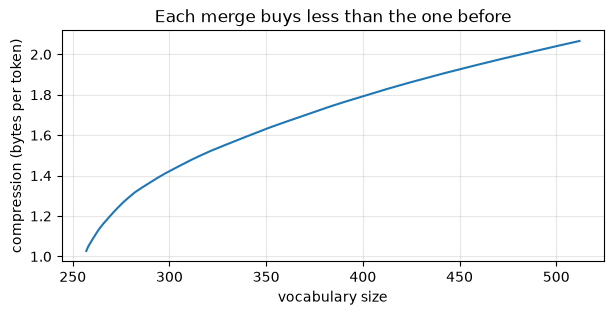

longest learned tokens: ['.\n\nCORIOLANUS:\n', '.\n\nMENENIUS:\n', 'MENENIUS:\n', 'RIOLANUS:\n', 'ICINIUS:\n', 'INIUS:\n', 'RIOLAN', 'First ', ',\nAnd ', ', and ', 'shall ', 'itizen', ' the ', 'IUS:\n', 'your ']


In [7]:
text = open('../transformer/input.txt', 'r').read()
slice_ = text[:200_000]

merges_shk, vocab_shk, history = train_bpe(slice_, vocab_size=512, verbose_first=8)

sizes, ratios = zip(*history)
print(f'\nfinal compression: {ratios[-1]:.2f} bytes/token with a 512-token vocab')

plt.figure(figsize=(7, 3))
plt.plot(sizes, ratios)
plt.xlabel('vocabulary size'); plt.ylabel('compression (bytes per token)')
plt.title('Each merge buys less than the one before')
plt.grid(alpha=0.3)
plt.show()

# The longest tokens the vocabulary assembled — whole words, learned purely from frequency.
longest = sorted(vocab_shk.values(), key=len, reverse=True)[:15]
print('longest learned tokens:', [t.decode("utf-8", errors="replace") for t in longest])


### What this buys the transformer

The transformer notebook's GPT reads 32 *characters* of context. Swap in this tokenizer and the same 32-position window covers ~2× the text at vocab 512 — and roughly 4 *words* per position at GPT-2's 50k vocab. Context windows are priced in tokens; the tokenizer sets the exchange rate to actual text. The changes to that notebook would be exactly two numbers: `vocab_size = 512` (growing the embedding table and the output layer) and re-encoding `input.txt` with `encode()` above. Everything else — attention, blocks, the training loop — is untouched. That's the sense in which the tokenizer is a *separate, swappable stage* in front of the model.


## Step 7: The weirdness that tokens explain

A model never sees characters — it sees token IDs. A whole genre of LLM folklore stops being mysterious the moment you look at the token boundaries. Each demo below runs on our Shakespeare tokenizer; every effect is far stronger at 50k–200k vocabulary, where whole words and multi-digit chunks are single tokens.

**Why counting letters is hard.** Ask a model how many `r`s are in *strawberry* and it must work from tokens like `st|raw|berry` — the individual letters are not in its input at all. To spell, it must have *memorized* each token's internal spelling from training-text examples, which works better for common tokens than rare ones.

**Why arithmetic is strange.** Numbers get carved by the same frequency statistics as everything else. In *our* tokenizer, digits survive as single bytes — Shakespeare contains almost no numerals, so no digit pair was ever frequent enough to merge. That's the vocabulary-mirrors-its-data point in its purest form. At 50k+ vocabulary trained on web text the problem inverts: `1000` might be one token while `1001` is two (`100|1`), so adjacent integers arrive with wildly different shapes, and digit-by-digit algorithms are hard to run when the grouping is inconsistent. (Several models now force digits into fixed-size groups for exactly this reason.)

**Why other languages cost more.** A BPE vocabulary mirrors its training data. Ours trained on Shakespeare's English, so English compresses well and everything else falls back toward raw bytes — more tokens for the same meaning. The same bias, softer but real, exists in production tokenizers trained on English-heavy data: the *same sentence* in another language burns more context window and costs more per API call.


In [8]:
def n_tokens(s): return len(encode(s, merges_shk))

# 1) Spelling: the model would see chunks, not letters.
show("strawberry", merges_shk, vocab_shk)

# 2) Numbers: Shakespeare has almost no numerals, so digits never earned a merge —
#    they pass through as lone bytes. The vocabulary mirrors its training data.
for num in ["1000", "2501"]:
    show(num, merges_shk, vocab_shk)

# 3) Language bias: same sentence, three languages, priced in tokens by OUR English tokenizer.
sentences = [('English', 'To be, or not to be, that is the question.'),
             ('Dutch',   'Zijn of niet zijn, dat is de vraag.'),
             ('Greek',   'Να ζει κανείς ή να μη ζει, ιδού η απορία.')]
print()
for lang, s in sentences:
    print(f'  {lang:8s} {len(s):3d} chars -> {n_tokens(s):3d} tokens   ({len(s)/n_tokens(s):.2f} chars/token)')


'strawberry'  ->  7 tokens:  [st | ra | w | b | er | r | y]
'1000'  ->  4 tokens:  [1 | 0 | 0 | 0]
'2501'  ->  4 tokens:  [2 | 5 | 0 | 1]

  English   42 chars ->  18 tokens   (2.33 chars/token)
  Dutch     35 chars ->  23 tokens   (1.52 chars/token)
  Greek     41 chars ->  70 tokens   (0.59 chars/token)


## Step 8: What production tokenizers add

Our tokenizer is the honest core of the real thing. Three refinements separate it from what GPT-2/4 and Llama actually ship:

**1. Regex pre-splitting.** Run merges on raw text and frequency will happily fuse across word boundaries — ` the` was fine, but nothing stops `e. The` or `t I` becoming tokens, and punctuation glues onto words (`dog.` vs `dog` as unrelated tokens). GPT-2's fix: before any BPE, a regex chops text into chunks (roughly: letter-runs, digit-runs, punctuation, each with its leading space), and **merges never cross chunk boundaries**. BPE then runs *within* each chunk. The cell below shows the difference on our corpus.

**2. Special tokens.** IDs appended *outside* the merge system with reserved meanings: `<|endoftext|>` separating documents in training data, and the chat-template tokens the finetuning notebook relied on (TinyLlama's `<|user|>` and `<|assistant|>`). They're handled by string matching before BPE ever runs, so no user text can produce them byte-by-byte — which is precisely what makes them trustworthy as *structure*: when the model sees `<|assistant|>`, it knows the turn changed, because nothing else can emit that ID.

**3. Scale, and one different lineage.** GPT-2: this exact byte-level BPE, 50,257 tokens (50k merges instead of our 256). GPT-4 and successors: same algorithm, ~100k–200k, better regex. Llama/TinyLlama use **SentencePiece**, a sibling that historically merged over characters with a byte fallback for the rest — different plumbing, same merge-by-frequency heart. Every tokenizer the finetuning notebook touches is one of these two lineages.


In [9]:
import re
# A simplified GPT-2-style splitter: optional leading space + letters, or digits, or punctuation, or whitespace.
# (The real one is fancier — Unicode categories, contractions like 're / 've — but this shows the idea.)
pat = re.compile(r" ?[A-Za-z]+| ?[0-9]+| ?[^A-Za-z0-9\s]+|\s+")

sample = "First Citizen: we'll have 100 corn at our own price. Is't a verdict?"
chunks = pat.findall(sample)
print('chunks:', chunks)

# BPE now runs inside each chunk separately; merges can never cross a chunk boundary.
ids_per_chunk = [encode(c, merges_shk) for c in chunks]
flat = [i for ids in ids_per_chunk for i in ids]
print(f'\nwith pre-splitting   : {len(flat)} tokens')
print(f'without (raw BPE)    : {len(encode(sample, merges_shk))} tokens')
print('MORE tokens with splitting?! Yes — only because OUR merges were trained without it,')
print('so chunk boundaries now cut through learned tokens like " the ". Production tokenizers')
print('train the merges WITH the same splitting, so nothing is lost — and every token is a')
print('clean word-piece instead of a "e. The"-style chimera that fuses two sentences.')


chunks: ['First', ' Citizen', ':', ' we', "'", 'll', ' have', ' 100', ' corn', ' at', ' our', ' own', ' price', '.', ' Is', "'", 't', ' a', ' verdict', '?']

with pre-splitting   : 47 tokens
without (raw BPE)    : 32 tokens
MORE tokens with splitting?! Yes — only because OUR merges were trained without it,
so chunk boundaries now cut through learned tokens like " the ". Production tokenizers
train the merges WITH the same splitting, so nothing is lost — and every token is a
clean word-piece instead of a "e. The"-style chimera that fuses two sentences.


## Summary

What we built, and how little it took:

| Component | What it does | Lines |
|-----------|-------------|-------|
| `get_stats` | Count adjacent pairs — the only statistic BPE ever uses | 5 |
| `merge` | Rewrite a sequence, fusing one pair into a new token | 10 |
| `train_bpe` | Loop the two above; record `merges` (the tokenizer itself) and `vocab` | 15 |
| `encode` / `decode` | Replay merges in training order / concatenate bytes back to text | 12 |

Roughly forty lines, and it is not a toy version of the idea — it *is* the idea. GPT-2's tokenizer is these forty lines plus a smarter regex, 50k merges instead of 256, and a fast implementation.

The series now connects end to end. A prompt you type into a chat model takes exactly this path: **bytes → BPE merges → token IDs** (this notebook) → **rows of an embedding table** ([embeddings](embeddings.ipynb)) → **attention and prediction** ([transformer](transformer.ipynb)), with the model's behavior shaped by **finetuning and preference optimization** ([finetuning](finetuning.ipynb)) — and every gradient in all of it computed by the backpropagation built by hand in the [neural network notebook](neural_net.ipynb).

### What we learned

- **A tokenizer is trained by counting, not gradient descent** — and the ordered list of merges *is* the tokenizer. Ship that list and you've shipped the tokenizer.
- **Starting from bytes means nothing is ever un-encodable**: a fixed 256-token base covers any text in any language, so byte-level BPE never needs an `<UNK>` token.
- **Every merge trades vocabulary for sequence length** — one more embedding row buys shorter inputs. The returns diminish (our compression curve flattened fast), which is why vocabularies stop at ~32k–200k instead of growing forever.
- **Encoding must replay merges in training order** — later merges were learned on top of earlier ones, so rank order, not frequency, decides what applies to new text.
- **`decode(encode(s)) == s` for every string** is the one hard correctness requirement.
- **The vocabulary mirrors its training data**: our Shakespeare tokenizer spends ~4× more tokens on Greek than English, and never merged a single digit pair. Production tokenizers have the same bias, softer.
- **Token boundaries explain LLM folklore** — models can't count letters they never see, do arithmetic on inconsistently-chunked digits, or price languages fairly when compression is unequal.
- **Special tokens live outside the merge system** — no user text can produce them byte-by-byte, which is exactly what makes them trustworthy as structure (`<|user|>`, `<|assistant|>`).

## Next steps

1. **Feed it back into the transformer.** Re-encode tiny Shakespeare with this tokenizer, set `vocab_size = 512` in the transformer notebook, and retrain the full GPT. Compare loss curves — note you can't compare cross-entropy directly (predicting 1-of-512 is a harder guess than 1-of-65); compare *per-character* by dividing each loss by its tokens' average character length.
2. **Study a production tokenizer.** `pip install tiktoken`, then round-trip text through `tiktoken.get_encoding('gpt2')` — inspect the same weirdness from Step 7 at 50k scale, where `strawberry` really is 3 chunks.
3. **Karpathy's [minbpe](https://github.com/karpathy/minbpe)** — the reference this notebook follows in spirit — adds the real GPT-2/GPT-4 regex patterns and special-token handling as exercises.


## Your turn: make it stick

Reading along is the comfortable half of learning. Before moving on, do these two things.

### 1. Summarize it yourself, then verify with an LLM

Close the notebook and write a summary from memory — a few sentences per question, no peeking:

- Why start from bytes instead of characters or words? What does the 256-token base buy you?
- What single statistic drives all of BPE training? What exactly gets stored as "the tokenizer"?
- Why must `encode` replay merges in training order rather than by frequency?
- What's the one hard correctness requirement for any tokenizer?
- Name three pieces of everyday LLM weirdness that token boundaries explain.

Then paste your summary into an LLM with a prompt like:

> *"I just built a byte-pair-encoding tokenizer from scratch. Here is my summary from memory: [your summary]. Check every claim for correctness, tell me what I've missed or muddled, then quiz me with three follow-up questions aimed at my weakest spot."*

### 2. Rebuild a small version

This is the fastest rebuild in the series — the whole thing is ~40 lines and needs nothing but Python:

1. From a blank file, write `get_stats`, `merge`, a training loop, and `encode`/`decode` from memory.
2. Train **50 merges on your own text** — an email you wrote, a README, code, anything that isn't Shakespeare. Using your own text matters: the learned tokens will be *your* vocabulary, which makes the "vocabulary mirrors its data" lesson land personally.
3. Print the 10 longest learned tokens and the compression ratio.

**Done when**: `decode(encode(s)) == s` holds for a string with an emoji and a non-English word in it, and you can explain each of your top-10 tokens ("of course — I say *actually* constantly"). Bonus: train the same 50 merges on someone else's text and compare the two vocabularies.

> ➡ **Next in the series:** [Fine-Tuning a Language Model with LoRA and DPO](finetuning.ipynb)
